# Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer

# Load training dataset using pandas

In [11]:
def read_data(file_path):
    return pd.read_csv(file_path)

# Data Preprocessing

In [12]:
def preprocess(df):
    df = df.drop(['Time', 'Place'], axis=1)
    return df

# Data Visualization

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_feature_correlations(df, target_column='Mag'):
    # Convert 'Time' to numeric before calculating correlation
    correlation_matrix = df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

    # Focus on correlation with target
    print("\nCorrelation with magnitude:")
    # Changed 'mag' to 'Mag' to match the actual column name
    print(correlation_matrix[target_column].sort_values(ascending=False))

# Split data into training and test data

In [14]:
def split_data(df):
    X = df.drop('Mag', axis=1)
    y = df['Mag']
    return train_test_split(X, y, test_size=0.2, random_state=42)

def impute_missing(X_train, X_test):
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)
    return X_train_imputed, X_test_imputed, imputer

# Model Training

In [18]:
def train_model(X_train, y_train, model_type):
    if model_type == 'linear':
        model = LinearRegression()
    elif model_type == 'decision_tree':
        model = DecisionTreeRegressor()
    elif model_type == 'random_forest':
        model = RandomForestRegressor()
    elif model_type == 'gradient_boosting':
        model = GradientBoostingRegressor()
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model.fit(X_train, y_train)
    return model


# Model Evaluation

In [16]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    return mse

def predict(model, imputer, input_data):
    input_data = imputer.transform([input_data])
    return model.predict(input_data)[0]


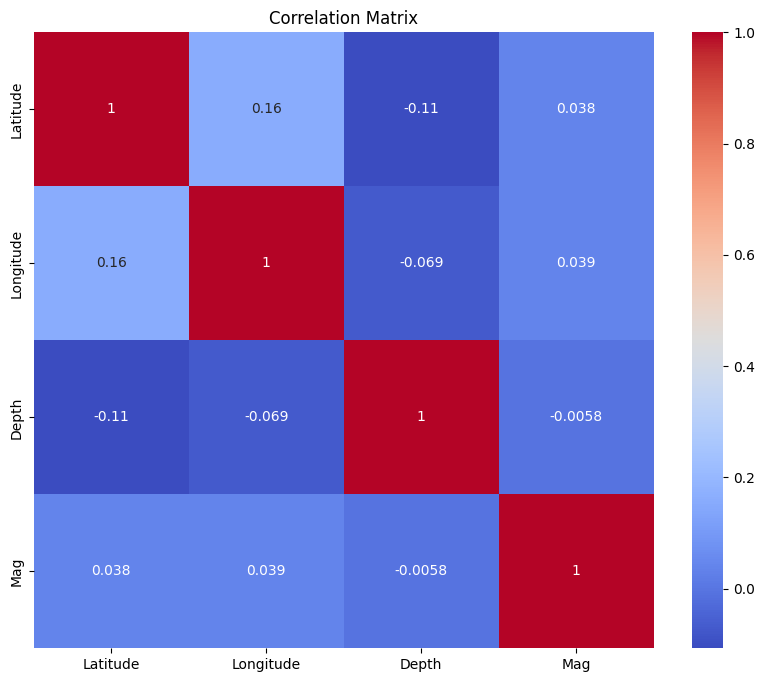


Correlation with magnitude:
Mag          1.000000
Longitude    0.039099
Latitude     0.037755
Depth       -0.005787
Name: Mag, dtype: float64
random_forest - Mean Squared Error: 0.2158
linear - Mean Squared Error: 0.2072
decision_tree - Mean Squared Error: 0.3754
gradient_boosting - Mean Squared Error: 0.1960

✅ Best Model: gradient_boosting with MSE = 0.1960
Predicted Magnitude using gradient_boosting: 5.91


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [20]:
file_path = "/content/Preprocessed_earthquake dataset (3).csv"  # Replace with correct path or upload

df = read_data(file_path)
df = preprocess(df)
plot_feature_correlations(df)

X_train, X_test, y_train, y_test = split_data(df)
X_train_imputed, X_test_imputed, imputer = impute_missing(X_train, X_test)

# Try all three models and track the one with the best performance
model_types = ["random_forest", "linear", "decision_tree", "gradient_boosting"]
results = {}

for model_type in model_types:
    model = train_model(X_train_imputed, y_train, model_type=model_type)
    mse = evaluate_model(model, X_test_imputed, y_test)
    results[model_type] = (model, mse)
    print(f"{model_type} - Mean Squared Error: {mse:.4f}")

# Select the best model (lowest MSE)
best_model_type = min(results, key=lambda x: results[x][1])
best_model, best_mse = results[best_model_type]

print(f"\n✅ Best Model: {best_model_type} with MSE = {best_mse:.4f}")

# Sample input — update according to your feature engineering
sample_input = [-6.59, 132.07, 38.615]  # [latitude, longitude, depth, timestamp]
predicted_mag = predict(best_model, imputer, sample_input)
print(f"Predicted Magnitude using {best_model_type}: {predicted_mag:.2f}")
